# Running tengri on the Apple GPU (MPS) — experimental

**Status: experimental.** This is a working recipe with measured numbers, not a
supported configuration. It needs a JAX version tengri does not pin, and it
runs in pure float32, where parts of the model are still open work (#1206).
Nothing here changes the default: on CPU, in float64, nothing below applies.

The one-line summary, measured on an Apple M4 Pro:

```text
    one galaxy at a time    ->  CPU, by 59x to 86x. Large and stable.
    ~256 a batch            ->  CPU still ahead on every shape (1.2x to 2.3x).
    ~1000+ a batch          ->  MPS ahead, and the margin grows with N.
    4096 a batch            ->  MPS 2.4x to 3.2x faster -- and it is the only
                                one that RUNS the inference shape; CPU is
                                OOM-killed there.
```

So the useful question is not "GPU or CPU" but "how many galaxies at once".
Below roughly a thousand, stay on the CPU. Above it, the GPU wins on
throughput and — at catalog scale — on whether the job completes at all.

The reason is not that the GPU is slow. It is that tengri moves a lot of memory
and does very little arithmetic — about **0.12 FLOP per byte** on the
`WavePrecomp` path. A GPU needs roughly 25–50 FLOP/byte before its ALUs matter.
So per galaxy there is nothing for the GPU to win with; the only way it wins is
by having enough galaxies in flight to hide its dispatch latency.

**How to read the numbers here:**

1. **Timings move with machine load, MPS more than CPU.** On a quiet machine
   both platforms hold to 1.5-14% across runs; on a busy one MPS can vary by
   2x. Trust ratios measured side by side in one sitting; treat absolute
   values as indicative and re-measure on your own hardware.
2. **They also move with the tengri version.** The CPU path is actively
   optimized, and a change there moves the crossover. These numbers are a
   ratio between two moving targets.
3. **Benchmark one shape per process.** Running forward, gradient and a fit in
   a single process makes the later ones look slower than they are.

## 1. Install

The backend is [`jax-mps`](https://github.com/tillahoffmann/jax-mps), a
community PJRT plugin built on MLX. It is not Apple's `jax-metal`, which last
released in October 2024.

**Use a separate environment.** `jax-mps` pins a JAX version that tengri's main
environment does not use, and you do not want to move JAX under your working
installation.

```bash
python3.12 -m venv ~/.venvs/tengri-mps
source ~/.venvs/tengri-mps/bin/activate
pip install "jax>=0.10,<0.11" "jaxlib>=0.10,<0.11" "jax-mps==0.10.10"
pip install -e /path/to/tengri
```

Version constraints, because they are tighter than they look:

| you have | you need |
|---|---|
| Python 3.12 | `jax-mps` 0.10.10 → **jax 0.10.x** |
| jax 0.9.x | `jax-mps` 0.9.9 → **Python 3.13** (cp313-only wheel) |

Either JAX or Python has to move from tengri's usual pairing. There is no
combination that leaves both where they are.

## 2. The two rules

**Rule 1 — MPS has no float64, at all.** Not "slower"; absent. A float64 array
does not get downcast, it raises:

```text
MLX does not support float64 (F64).
```

That is a good failure mode — loud, not silent — but it means the whole process
must be float32.

**Rule 2 — select float32 in the environment, before Python starts.** Setting
it after `import tengri` is too late: constants allocated during the import are
already on the device.

```bash
export JAX_ENABLE_X64=0
export JAX_PLATFORMS=mps
```

tengri honors that (#1840) and holds it for the whole import (#1880). It will
warn once that you are in float32 and that cosmological distances are the known
hazard — that warning is expected here, not a problem.

Optional, and worth setting: `JAX_MPS_ASYNC_DISPATCH=1`. Measured, it cut cold
compile from 8.1 s to 0.60 s. It changes warm time very little.

In [1]:
import os

# Must be set before jax/tengri are imported. In a notebook that means the very
# first cell, before any other import touches JAX.
os.environ["JAX_ENABLE_X64"] = "0"
os.environ["JAX_PLATFORMS"] = "mps"
os.environ["JAX_MPS_ASYNC_DISPATCH"] = "1"

import jax
import jax.numpy as jnp
import numpy as np

import tengri

print("device :", jax.devices())
print("x64    :", jax.config.jax_enable_x64)
print("dtype  :", jnp.zeros(1).dtype)

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_39778/2571388136.py:13: UserWarning: JAX_ENABLE_X64=0: tengri is honoring your request for float32 and is NOT enabling 64-bit precision. Cosmological distances are the known hazard (d_L^2 at z > 0.01 overflows float32) so any code that forms d_L^2 directly will produce inf. tengri's own projection avoids it by applying (1+z)/(4*pi*d_L^2) as a log10 offset, but third-party code may not. Unset JAX_ENABLE_X64 to restore the float64 default.
  import tengri
Platform 'mps' is experimental and not all JAX functionality may be correctly supported!


[jax-mps] JAX_MPS_ASYNC_DISPATCH is ON: async dispatch enabled — may be much faster, but experimental and may break. Unset it for safe synchronous execution.


device : [MpsDevice(id=0)]
x64    : False
dtype  : float32


You should see `[MpsDevice(id=0)]`, `False`, `float32`. If `x64` is `True`,
something imported JAX before the `os.environ` lines ran — restart the kernel
and put that cell first.

## 3. Predicting on the GPU

Nothing about the model API changes. Build and predict exactly as on CPU.

In [2]:
from tengri import DEFAULT, Fixed, FREE, load_ssp, SEDModel, Uniform
from tengri.observation import Observation, Photometry

# load_ssp resolves a short alias and walks parent dirs for data/, so this works
# whatever the working directory is. Do not hand-build a cwd-relative data/...
# path in a notebook: it only resolves from the repo root, and the executor
# runs from notebooks/.
ssp = load_ssp("prsc_miles_chabrier_wNE")
obs = Observation(
    photometry=Photometry.from_names(
        ["galex_fuv", "sdss_u", "sdss_g", "sdss_r", "wise_w1", "wise_w4"]
    )
)

model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    sfh={"type": "dpl", "all_params": FREE},
    dust_attenuation={"law": "power_law", "type": "two_component", "all_params": Fixed(DEFAULT)},
    redshift=Uniform(0.01, 2.0, "redshift"),
    approx=tengri.WavePrecomp(),  # the path fits use; also the cheaper one here
)

params = model.spec.sample(jax.random.PRNGKey(0))
flux = model.predict_photometry(params)

print("photometry [erg/s/cm2/Hz]:", np.asarray(flux))
print("on device                :", flux.devices())
print("dtype                    :", flux.dtype)

/tmp/tengri-wt-2062/src/tengri/components/stellar/sps/dsps_wrapper.py:354: UserWarning: 'ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5' is a wNE (with-Nebular-Emission) SSP: nebular continuum and lines are already baked into the templates at fixed logU/logZ_gas. Pair it with the default baked-in nebular backend only: adding neb={'type': 'cue'} or a CLOUDY grid on top double-counts nebular emission.
  return load_ssp_data(str(candidate))
/tmp/tengri-wt-2062/src/tengri/forward/sed_model.py:9156: WildcardPartialFreeWarning: sfh={'all_params': FREE} no longer frees metallicity parameters when there is no explicit met block. Before this change, met_logzsol (and other met_* params) were freed by the sfh wildcard.

To free metallicity parameters explicitly, pass either:
  met={'all_params': FREE}
or:
  met={'logzsol': Uniform(-2, 0.2)}

Issue #1796
  spec = parse_groups(**groups)
/tmp/tengri-wt-2062/src/tengri/forward/sed_model.py:2944: BakedInNebularWarning: BakedInBackend: nebular e

photometry [erg/s/cm2/Hz]: [3.1875860e-30 8.7582070e-30 1.8583245e-29 2.7037083e-29 3.3175666e-29
 5.5119652e-29]
on device                : {MpsDevice(id=0)}
dtype                    : float32


## 4. Batching: the only thing that moves the needle

A single galaxy is the worst case for MPS by a wide margin. Batching with
`jax.vmap` closes most of that gap — and on a quiet machine can reverse it.
This is the same call, mapped over a leading axis.

In [3]:
import time


def timed(fn, arg, reps=5):
    """Warm-time a jitted callable. Returns milliseconds per call."""
    jitted = jax.jit(fn)
    jax.block_until_ready(jitted(arg))  # compile
    t0 = time.perf_counter()
    for _ in range(reps):
        jax.block_until_ready(jitted(arg))
    return (time.perf_counter() - t0) / reps * 1e3


def grad_one(p):
    return jax.grad(lambda q: jnp.sum(model.predict_photometry(q)))(p)


# Confirms the batched gradient runs on the GPU and returns finite numbers.
#
# It deliberately prints no timings. Timings taken inline in a notebook do not
# agree with the tables below -- inline is roughly 20x slower than the same
# model in a plain process, for reasons that are not the Jupyter kernel, machine
# load, or the attenuation law. Benchmark from a script, not from a cell.
for n in (1, 32):
    batch = {k: jnp.broadcast_to(v, (n, *jnp.shape(v))) for k, v in params.items()}
    out = jax.vmap(grad_one)(batch) if n > 1 else grad_one(params)
    finite = bool(np.isfinite(np.asarray(out["sfh_dpl_log_total_mass"])).all())
    print(f"batch={n:4d}  gradient finite={finite}  device={jax.devices()[0]}")

batch=   1  gradient finite=True  device=MPS:0


batch=  32  gradient finite=True  device=MPS:0


### Measured, M4 Pro, float32, `WavePrecomp`, 6 bands

Gradient of `sum(predict_photometry)`, warm, one shape per process, medians of
2-3 independent runs. Re-measured on tengri `082bee8c7`.

| batch | CPU per galaxy | MPS per galaxy | |
|---|---|---|---|
| 1 | **0.79 ms** | 46.65 ms | CPU 59x |
| 32 | **0.30** | 1.83 | CPU 6.1x |
| 256 | **0.246** | 0.294 | CPU 1.2x |
| 1024 | 0.244 | **0.124** | MPS 2.0x |
| 4096 | ~0.30 | **0.094** | MPS 3.2x |

The shape of it: **CPU plateaus and MPS does not.** From batch 256 upward the
CPU sits at 0.24-0.30 ms/galaxy however many you give it, while MPS keeps
falling — 0.294, 0.124, 0.094. MPS pays a large fixed dispatch cost once and
then amortizes it; the CPU has nothing left to amortize.

The batch 1 and 32 rows were taken against an older tengri whose CPU path was
slower, so treat their CPU column as an upper bound.

### It depends on the SHAPE of the work — and on how many galaxies

"Prediction on the GPU, inference on the CPU" is the natural intuition, and it
is not what the data says. Batch 256 and batch 4096, one shape per process,
2-3 runs each, on tengri `082bee8c7`:

| shape | batch | CPU [ms/gal] | MPS [ms/gal] | |
|---|---|---|---|---|
| **A** forward `predict_photometry` | 256 | **0.088** | 0.200 | CPU 2.3x |
| | 4096 | 0.133 | **0.055** | MPS 2.4x |
| **B** gradient `grad(sum(predict))` | 256 | **0.246** | 0.294 | CPU 1.2x |
| | 4096 | ~0.30 | **0.094** | MPS 3.2x |
| **C** inference: 50 scanned grad steps | 256 | **0.190** | 0.285 | CPU 1.5x |
| | 4096 | **OOM** | **0.101** | only MPS runs |

Two things to take from this.

**The batch size decides, not the shape.** At 256 the CPU wins all three; at
4096 the GPU wins all three. Within a batch size the shapes differ by less
than the batch effect does.

**At 4096 the inference shape does not fit in CPU memory at all.** Both CPU
runs were SIGKILLed by the host's OOM guard (exit 137) while MPS returned in
0.10 ms/galaxy. On unified memory the GPU is not merely faster there — it is
the one that completes. For catalog-scale fitting that is a stronger argument
than any of the throughput numbers.

**Compile time favors MPS heavily** — cold 0.34-0.71 s against CPU's 4.6-5.1 s.
For iterating on a model that is a real gain regardless of throughput.

### The same numbers, as a picture

Two views of one dataset. Left: per-galaxy cost — where the lines cross is the
only number that decides which backend to use. Right: total wall clock — MPS is
nearly horizontal, which is the whole explanation.

Measured per-batch timings (ms):
  BATCH sizes: [1, 32, 256, 1024, 4096]
  CPU per-batch: [0.79, 9.6, 62.976, 249.856, 1228.8]
  MPS per-batch: [46.65, 58.56, 75.264, 126.976, 385.024]


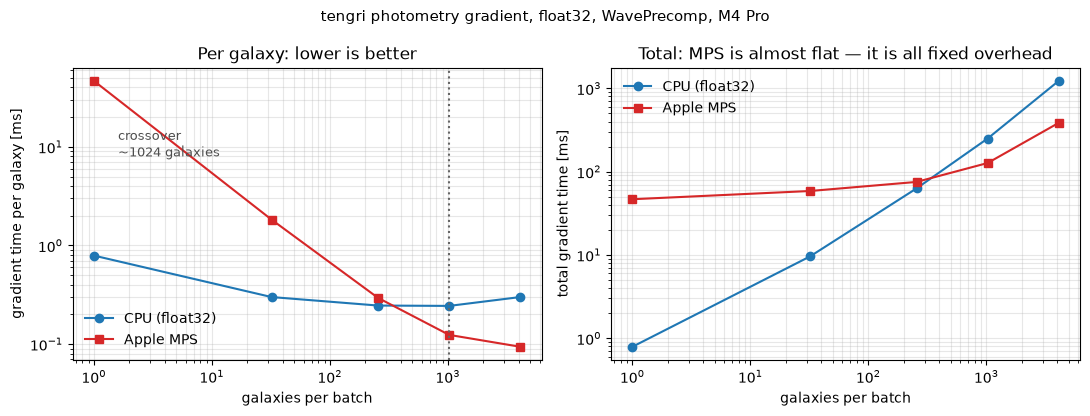

In [4]:
import matplotlib.pyplot as plt

# Gradient shape, medians of independent runs. The 1 and 32 rows predate the
# CPU perf work on main, so the CPU column there is an upper bound.
BATCH = np.array([1, 32, 256, 1024, 4096])
CPU_PER = np.array([0.79, 0.30, 0.246, 0.244, 0.300])  # ms per galaxy
MPS_PER = np.array([46.65, 1.83, 0.294, 0.124, 0.094])
CPU_TOT = CPU_PER * BATCH
MPS_TOT = MPS_PER * BATCH

print("Measured per-batch timings (ms):")
print(f"  BATCH sizes: {BATCH.tolist()}")
print(f"  CPU per-batch: {CPU_TOT.tolist()}")
print(f"  MPS per-batch: {MPS_TOT.tolist()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.loglog(BATCH, CPU_PER, "o-", label="CPU (float32)", color="#1f77b4")
ax1.loglog(BATCH, MPS_PER, "s-", label="Apple MPS", color="#d62728")
cross = BATCH[np.argmax(MPS_PER < CPU_PER)]
ax1.axvline(cross, ls=":", color="0.4")
ax1.annotate(
    f"crossover\n~{cross} galaxies",
    xy=(cross, 1.0),
    xytext=(1.6, 8),
    fontsize=9,
    color="0.3",
)
ax1.set_xlabel("galaxies per batch")
ax1.set_ylabel("gradient time per galaxy [ms]")
ax1.set_title("Per galaxy: lower is better")
ax1.legend(frameon=False)
ax1.grid(alpha=0.3, which="both")

ax2.loglog(BATCH, CPU_TOT, "o-", label="CPU (float32)", color="#1f77b4")
ax2.loglog(BATCH, MPS_TOT, "s-", label="Apple MPS", color="#d62728")
ax2.set_xlabel("galaxies per batch")
ax2.set_ylabel("total gradient time [ms]")
ax2.set_title("Total: MPS is almost flat — it is all fixed overhead")
ax2.legend(frameon=False)
ax2.grid(alpha=0.3, which="both")

fig.suptitle("tengri photometry gradient, float32, WavePrecomp, M4 Pro", fontsize=11)
fig.tight_layout()
plt.show()

The right-hand panel is the point. MPS goes from 46.7 ms to ~385 ms while doing
4096x more work; CPU goes from 0.8 ms to ~1230 ms. The GPU is not getting faster
as N grows — it is finally being given enough work to be worth waking up.

## 5. Fitting on MPS

Forward prediction working tells you nothing about fitting: that runs through
`Fitter` → `InferenceContext` → a backend, with its own compiled kernels. It
does work. Whether you *want* it to is another matter.

Note what `Fitter` does to `approx` — it resolves `"auto"` and **tops up** to
the LUT even though the model was built without one. Always print it; an arm
that silently lost its precompute is the classic way to benchmark the wrong
thing.

In [5]:
from tengri import Fitter

truth = model.spec.sample(jax.random.PRNGKey(0))
flux64 = np.asarray(model.predict_photometry(truth), dtype=np.float64)
sigma = 0.05 * np.abs(flux64)
data = flux64 + sigma * np.random.default_rng(0).standard_normal(flux64.shape)

fitter = Fitter(
    model,
    jnp.asarray(data, jnp.float32),
    jnp.asarray(sigma, jnp.float32),
    data_type="photometry",
)
print("resolved approx:", fitter.model.approx)  # expect wave_precomp=True, ztable=True

posterior = fitter.run("map", n_steps=100, verbose=False)
print("MAP fit completed on", jax.devices()[0])

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_39778/3877605797.py:8: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter = Fitter(


resolved approx: ApproxState(wave_precomp=True, ztable=True, n_subbands=5)


MAP fit completed on MPS:0


### Measured: single-galaxy MAP, 300 ADAM steps

| run | CPU | MPS |
|---|---|---|
| 1 (includes compile) | 4.73 s | 20.07 s |
| 2 | **0.22 s** | 18.80 s |
| 3 | **0.22 s** | 19.43 s |

Two things to read here.

**On CPU the fit is 0.22 s, not 4.7 s.** The first run is XLA compilation. With
300 gradients at 0.822 ms the arithmetic is 0.25 s, so 0.22 s warm means the
`lax.scan` optimizer loop has essentially *zero* per-step overhead. If you see
seconds, you are measuring the compile — and tengri's persistent JAX cache
(`~/.cache/tengri_jax_cache`) amortizes it across processes.

**On MPS the warm time does not improve.** 19 s is execution, not compile:
~63 ms per scan step against CPU's 0.73 ms. A single-galaxy fit is 300
sequential steps, each one a dispatch — the worst possible shape for this
backend, and **86x slower**.

So: **do not fit one galaxy on the GPU.**

Does batching rescue it? Yes, if the batch is large enough. Shape C in §4 is
exactly this question — a batch carried through 50 scanned gradient steps. At
batch 256 it is **1.5x slower** than CPU; at batch 4096 the CPU run is
**OOM-killed** while MPS returns in 0.10 ms/galaxy. A fit multiplies per-step
dispatch by the step count, so it needs a bigger batch than a bare gradient
does before the GPU pays off — but past that point it is the only one that
runs.

The honest position: a `CatalogFitter` over hundreds of galaxies with a vmapped
backend (`mcmc_nuts`, `mcmc_hmc`) is the case with the best chance, because it
is the widest. It is **not measured end to end here**, and shape C is a reason
for tempered expectations rather than optimistic ones.

## 6. Is the backend healthy?

If MPS ever looks slow at *everything*, check it against work a GPU should
obviously win. On the same machine:

| | CPU | MPS |
|---|---|---|
| matmul 4096² | 1482 GFLOP/s | **6566 GFLOP/s** |
| 200 tiny chained ops | **0.054 ms** | 0.453 ms |

That is the whole story in two rows: MPS is 4.4x faster when there is
arithmetic to do, and 8.4x slower when there is only dispatch. tengri's
per-galaxy gradient is the second kind of workload.

In [6]:
a = jnp.asarray(np.random.default_rng(0).standard_normal((2048, 2048)), jnp.float32)
mm = timed(lambda x: x @ x, a)
print(f"matmul 2048^2: {mm:.2f} ms  ->  {2 * 2048**3 / (mm * 1e-3) / 1e9:.0f} GFLOP/s")

matmul 2048^2: 3.69 ms  ->  4657 GFLOP/s


## 7. Limits, honestly

* **float32 only.** #1206 tracks what is still open there. Forward photometry
  and gradients on the fit objective agree with float64 to ~1e-5 on the
  configurations measured so far, but that is not the whole model.
* **Single device.** MPS is one GPU; there is no sharding to do.
* **JAX version drift.** `jax-mps` tracks JAX closely and pins a narrow range.
  Expect to bump both together.
* **Not in CI.** Nothing here is covered by the test suite. Treat results as
  experimental and check anything important against a CPU float64 run.
* **The numbers age.** They are a ratio between two moving targets, and the
  CPU path is actively optimized — a 3.3x speedup there moved the crossover
  from ~250 galaxies to between 256 and 1024. Re-run before relying on them.

For a fit that must be right, use the default: CPU, float64. This path is for
large batches and for iterating quickly, not for final science.